In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

import seaborn as sns

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploaded = files.upload()

Saving task3.zip to task3.zip


In [48]:
import zipfile

zip_path = "task3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/intel_dataset")

In [50]:
import os

for root, dirs, files in os.walk("/content/intel_dataset"):
    print(root)
    print(dirs[:10])
    break

/content/intel_dataset
['seg_test', 'seg_train', 'seg_pred']


In [51]:
train_dir = "/content/intel_dataset/seg_train/seg_train"
test_dir = "/content/intel_dataset/seg_test/seg_test"

In [52]:
class_names = os.listdir(train_dir)

print(class_names)

['buildings', 'sea', 'street', 'glacier', 'mountain', 'forest']


In [53]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [54]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 14034 files belonging to 6 classes.


In [55]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


In [56]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,

    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [57]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 11932 images belonging to 6 classes.


In [58]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2102 images belonging to 6 classes.


In [59]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [60]:
print(train_generator.class_indices)

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


In [61]:
classes = sorted(os.listdir(train_dir))

print(classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


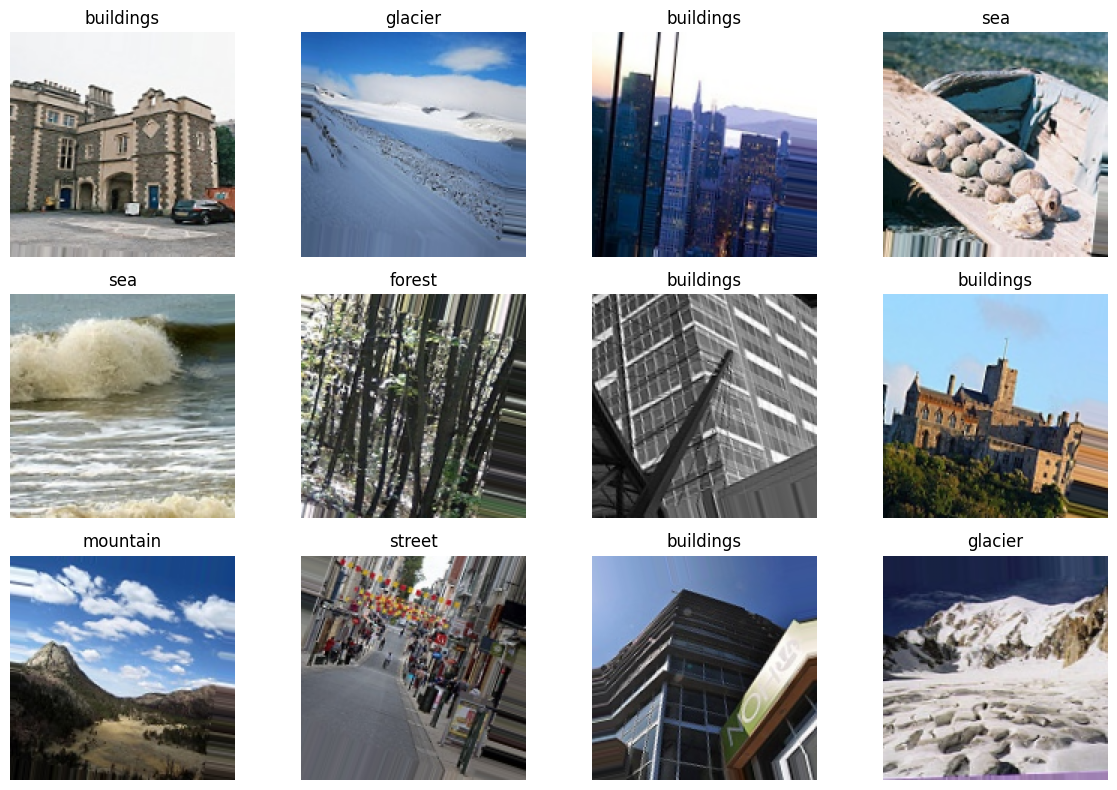

In [62]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    class_name = classes[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [63]:
input_shape = (150, 150, 3)

inpt_img = Input(shape=input_shape)

# First Convolution
c11 = Conv2D(
    64,
    (9, 9),
    strides=(2, 2),
    activation='relu'
)(inpt_img)

p12 = MaxPooling2D(pool_size=(2, 2))(c11)

bn13 = BatchNormalization()(p12)


# Second Convolution
c14 = Conv2D(
    128,
    (3, 3),
    strides=(1, 1),
    activation='relu'
)(bn13)

p15 = MaxPooling2D(pool_size=(2, 2))(c14)

bn16 = BatchNormalization()(p15)


# Flatten
f17 = Flatten()(bn16)


# Dense + Dropout
do18 = Dropout(0.5)(f17)

d19 = Dense(
    units=256,
    activation='relu'
)(do18)

do110 = Dropout(0.3)(d19)

d111 = Dense(
    units=64,
    activation='relu'
)(do110)

do112 = Dropout(0.2)(d111)


# Output
output = Dense(
    units=6,
    activation='softmax'
)(do112)


classifier = Model(
    inputs=inpt_img,
    outputs=output
)

In [64]:
print(classifier.summary())

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 71, 71, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 35, 35, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,495,942 (32.41 MB)

 Trainable params: 8,495,558 (32.41 MB)

 Non-trainable params: 384 (1.50 KB)

None


In [65]:
opt = RMSprop(
    learning_rate=0.001
)

classifier.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [66]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint_filepath = "/content/cnn_intel_best.h5"

model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [68]:
hist = classifier.fit(
    train_generator,

    epochs=30,

    validation_data=val_generator,

    callbacks=[
        stop_alg,
        reduce_lr,
        model_checkpoint
    ]
)

Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.3669 - loss: 3.2539
Epoch 1: val_accuracy improved from None to 0.46908, saving model to /content/cnn_intel_best.h5



Epoch 1: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 97s 245ms/step - accuracy: 0.3930 - loss: 2.1959 - val_accuracy: 0.4691 - val_loss: 1.3854 - learning_rate: 0.0010
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4585 - loss: 1.5176
Epoch 2: val_accuracy improved from 0.46908 to 0.49191, saving model to /content/cnn_intel_best.h5



Epoch 2: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 84s 225ms/step - accuracy: 0.4723 - loss: 1.4343 - val_accuracy: 0.4919 - val_loss: 1.9293 - learning_rate: 0.0010
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5102 - loss: 1.3156
Epoch 3: val_accuracy improved from 0.49191 to 0.59324, saving model to /content/cnn_intel_best.h5



Epoch 3: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - accuracy: 0.5211 - loss: 1.2933 - val_accuracy: 0.5932 - val_loss: 1.0883 - learning_rate: 0.0010
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.5416 - loss: 1.2386
Epoch 4: val_accuracy did not improve from 0.59324
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 224ms/step - accuracy: 0.5489 - loss: 1.2093 - val_accuracy: 0.3839 - val_loss: 4.3698 - learning_rate: 0.0010
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5688 - loss: 1.1517
Epoch 5: val_accuracy did not improve from 0.59324
373/373 ━━━━━━━━━━━━━━━━━━━━ 81s 217ms/step - accuracy: 0.5747 - loss: 1.1481 - val_accuracy: 0.5561 - val_loss: 1.9139 - learning_rate: 0.0010
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5852 - loss: 1.1228
Epoch 6: val_accuracy did not improve from 0.59324
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 224ms/step - accuracy: 0.5927 - loss: 1.1066 - val_accur


Epoch 7: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - accuracy: 0.6189 - loss: 1.0704 - val_accuracy: 0.6551 - val_loss: 0.9657 - learning_rate: 0.0010
Epoch 8/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6288 - loss: 1.0414
Epoch 8: val_accuracy improved from 0.65509 to 0.69743, saving model to /content/cnn_intel_best.h5


...


Epoch 14: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 215ms/step - accuracy: 0.7119 - loss: 0.8346 - val_accuracy: 0.7369 - val_loss: 0.7929 - learning_rate: 5.0000e-04
Epoch 15/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7220 - loss: 0.8294
Epoch 15: val_accuracy did not improve from 0.73692
373/373 ━━━━━━━━━━━━━━━━━━━━ 79s 211ms/step - accuracy: 0.7215 - loss: 0.8200 - val_accuracy: 0.7108 - val_loss: 1.0229 - learning_rate: 5.0000e-04
Epoch 16/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7262 - loss: 0.7958
Epoch 16: val_accuracy improved from 0.73692 to 0.76070, saving model to /content/cnn_intel_best.h5



Epoch 16: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 79s 213ms/step - accuracy: 0.7285 - loss: 0.7959 - val_accuracy: 0.7607 - val_loss: 0.7157 - learning_rate: 5.0000e-04
Epoch 17/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7448 - loss: 0.7757
Epoch 17: val_accuracy did not improve from 0.76070
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 215ms/step - accuracy: 0.7389 - loss: 0.7849 - val_accuracy: 0.7431 - val_loss: 0.7601 - learning_rate: 5.0000e-04
Epoch 18/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7515 - loss: 0.7567
Epoch 18: val_accuracy did not improve from 0.76070
373/373 ━━━━━━━━━━━━━━━━━━━━ 87s 235ms/step - accuracy: 0.7458 - loss: 0.7601 - val_accuracy: 0.7207 - val_loss: 0.7763 - learning_rate: 5.0000e-04
Epoch 19/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7471 - loss: 0.7582
Epoch 19: val_accuracy did not improve from 0.76070
373/373 ━━━━━━━━━━━━━━━━━━━━ 79s 211ms/step - accuracy: 0.7430 - loss:


Epoch 20: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 89s 240ms/step - accuracy: 0.7402 - loss: 0.7737 - val_accuracy: 0.7650 - val_loss: 0.7328 - learning_rate: 5.0000e-04
Epoch 21/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.7423 - loss: 0.7543
Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 21: val_accuracy did not improve from 0.76499
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 213ms/step - accuracy: 0.7442 - loss: 0.7607 - val_accuracy: 0.7265 - val_loss: 0.8052 - learning_rate: 5.0000e-04
Epoch 22/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7640 - loss: 0.7026
Epoch 22: val_accuracy improved from 0.76499 to 0.79258, saving model to /content/cnn_intel_best.h5



Epoch 22: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 213ms/step - accuracy: 0.7656 - loss: 0.7007 - val_accuracy: 0.7926 - val_loss: 0.6257 - learning_rate: 2.5000e-04
Epoch 23/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7676 - loss: 0.6995
Epoch 23: val_accuracy did not improve from 0.79258
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 216ms/step - accuracy: 0.7668 - loss: 0.7069 - val_accuracy: 0.7693 - val_loss: 0.8117 - learning_rate: 2.5000e-04
Epoch 24/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7684 - loss: 0.6852
Epoch 24: val_accuracy did not improve from 0.79258
373/373 ━━━━━━━━━━━━━━━━━━━━ 78s 210ms/step - accuracy: 0.7696 - loss: 0.6828 - val_accuracy: 0.7797 - val_loss: 0.6765 - learning_rate: 2.5000e-04
Epoch 25/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7690 - loss: 0.7211
Epoch 25: val_accuracy did not improve from 0.79258
373/373 ━━━━━━━━━━━━━━━━━━━━ 78s 210ms/step - accuracy: 0.7682 - loss:


Epoch 26: finished saving model to /content/cnn_intel_best.h5
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 214ms/step - accuracy: 0.7709 - loss: 0.6990 - val_accuracy: 0.8102 - val_loss: 0.5852 - learning_rate: 2.5000e-04
Epoch 27/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7675 - loss: 0.7080
Epoch 27: val_accuracy did not improve from 0.81018
373/373 ━━━━━━━━━━━━━━━━━━━━ 79s 212ms/step - accuracy: 0.7714 - loss: 0.6996 - val_accuracy: 0.7298 - val_loss: 0.7656 - learning_rate: 2.5000e-04
Epoch 28/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7737 - loss: 0.6710
Epoch 28: val_accuracy did not improve from 0.81018
373/373 ━━━━━━━━━━━━━━━━━━━━ 80s 214ms/step - accuracy: 0.7747 - loss: 0.6820 - val_accuracy: 0.7336 - val_loss: 0.8131 - learning_rate: 2.5000e-04
Epoch 29/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.7684 - loss: 0.6959
Epoch 29: val_accuracy did not improve from 0.81018
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accuracy: 0.7741 - loss:

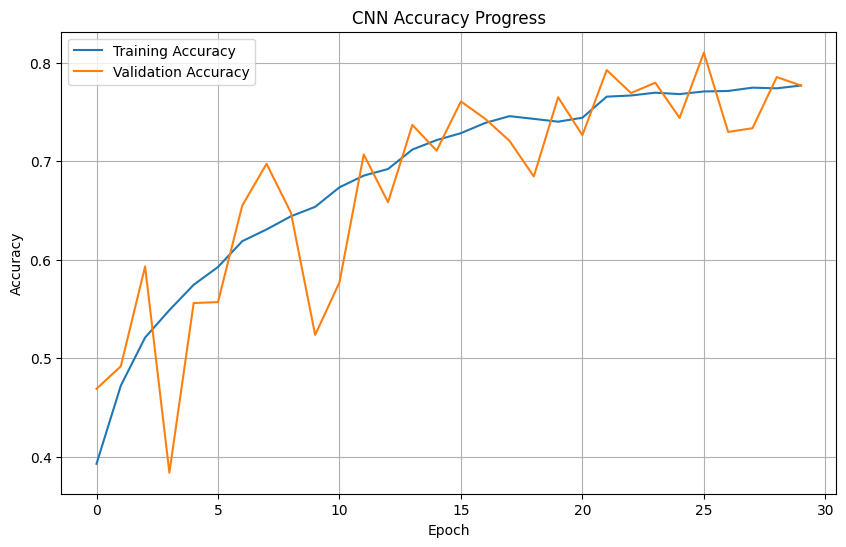

In [69]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    hist.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid()

plt.show()

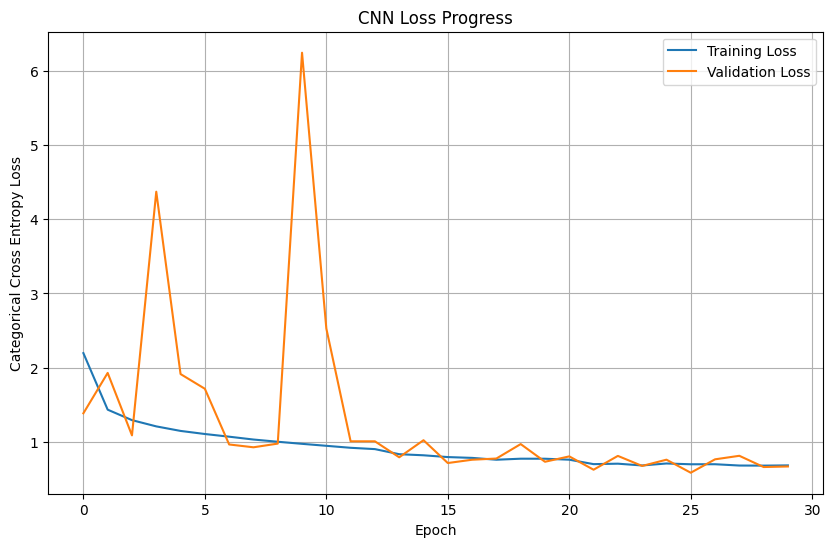

In [70]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist.history['loss'],
    label='Training Loss'
)

plt.plot(
    hist.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Loss Progress')
plt.xlabel('Epoch')
plt.ylabel('Categorical Cross Entropy Loss')

plt.legend()
plt.grid()

plt.show()

In [71]:
test_loss, test_accuracy = classifier.evaluate(
    test_generator
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8267 - loss: 0.8584
Test Loss: 0.8584174513816833
Test Accuracy: 0.8266666531562805


In [72]:
test_generator.reset()

y_prob = classifier.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

y_true = test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step


In [73]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

              precision    recall  f1-score   support

   buildings       0.76      0.84      0.80       437
      forest       0.97      0.94      0.95       474
     glacier       0.81      0.78      0.79       553
    mountain       0.79      0.75      0.77       525
         sea       0.79      0.83      0.81       510
      street       0.85      0.84      0.84       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



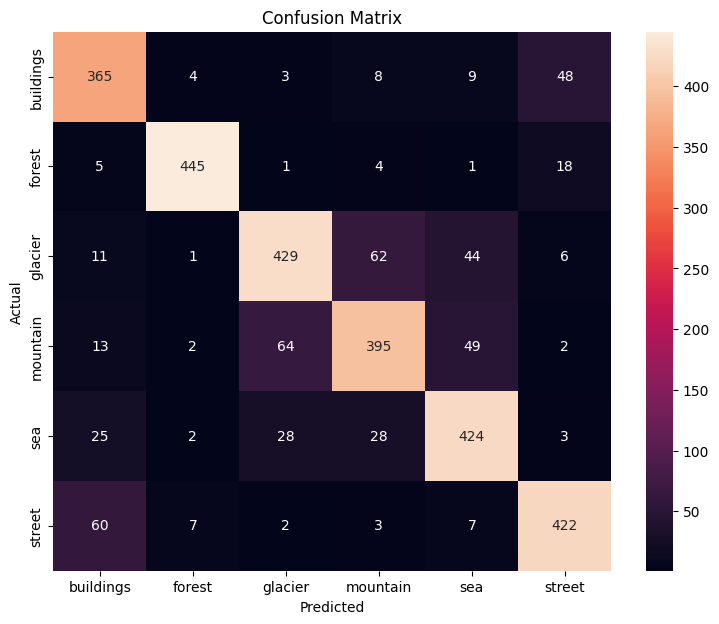

In [74]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [75]:
balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

ber = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber)

Balanced Accuracy: 0.8293160409874382
BER: 0.17068395901256184


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step


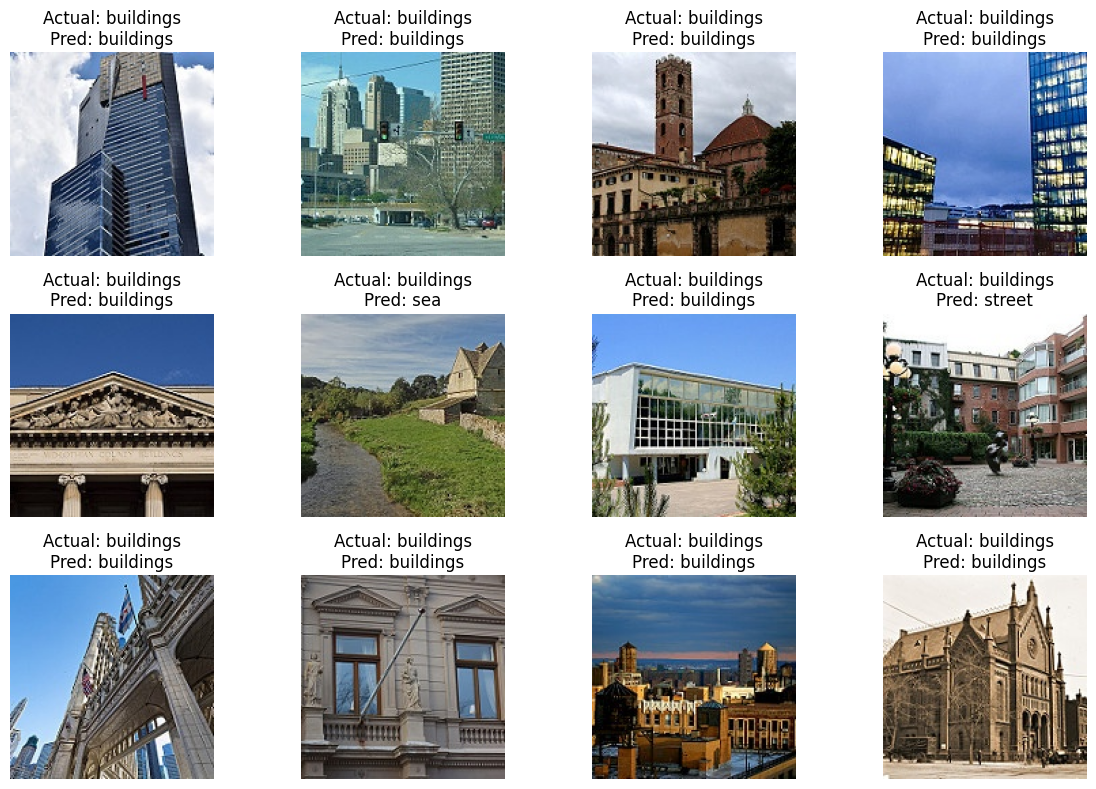

In [76]:
images, labels = next(test_generator)

predictions = classifier.predict(images)

plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i])

    actual = classes[np.argmax(labels[i])]
    predicted = classes[np.argmax(predictions[i])]

    plt.title(
        f"Actual: {actual}\nPred: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [77]:
from sklearn.preprocessing import MinMaxScaler

conv_layer = classifier.get_layer(
    index=1
)

weights = conv_layer.get_weights()[0]

print("Filter shape:", weights.shape)

Filter shape: (9, 9, 3, 64)


In [78]:
scaler = MinMaxScaler()

scaled_weights = scaler.fit_transform(
    weights.reshape(-1, 1)
)

scaled_weights = scaled_weights.reshape(
    weights.shape
)

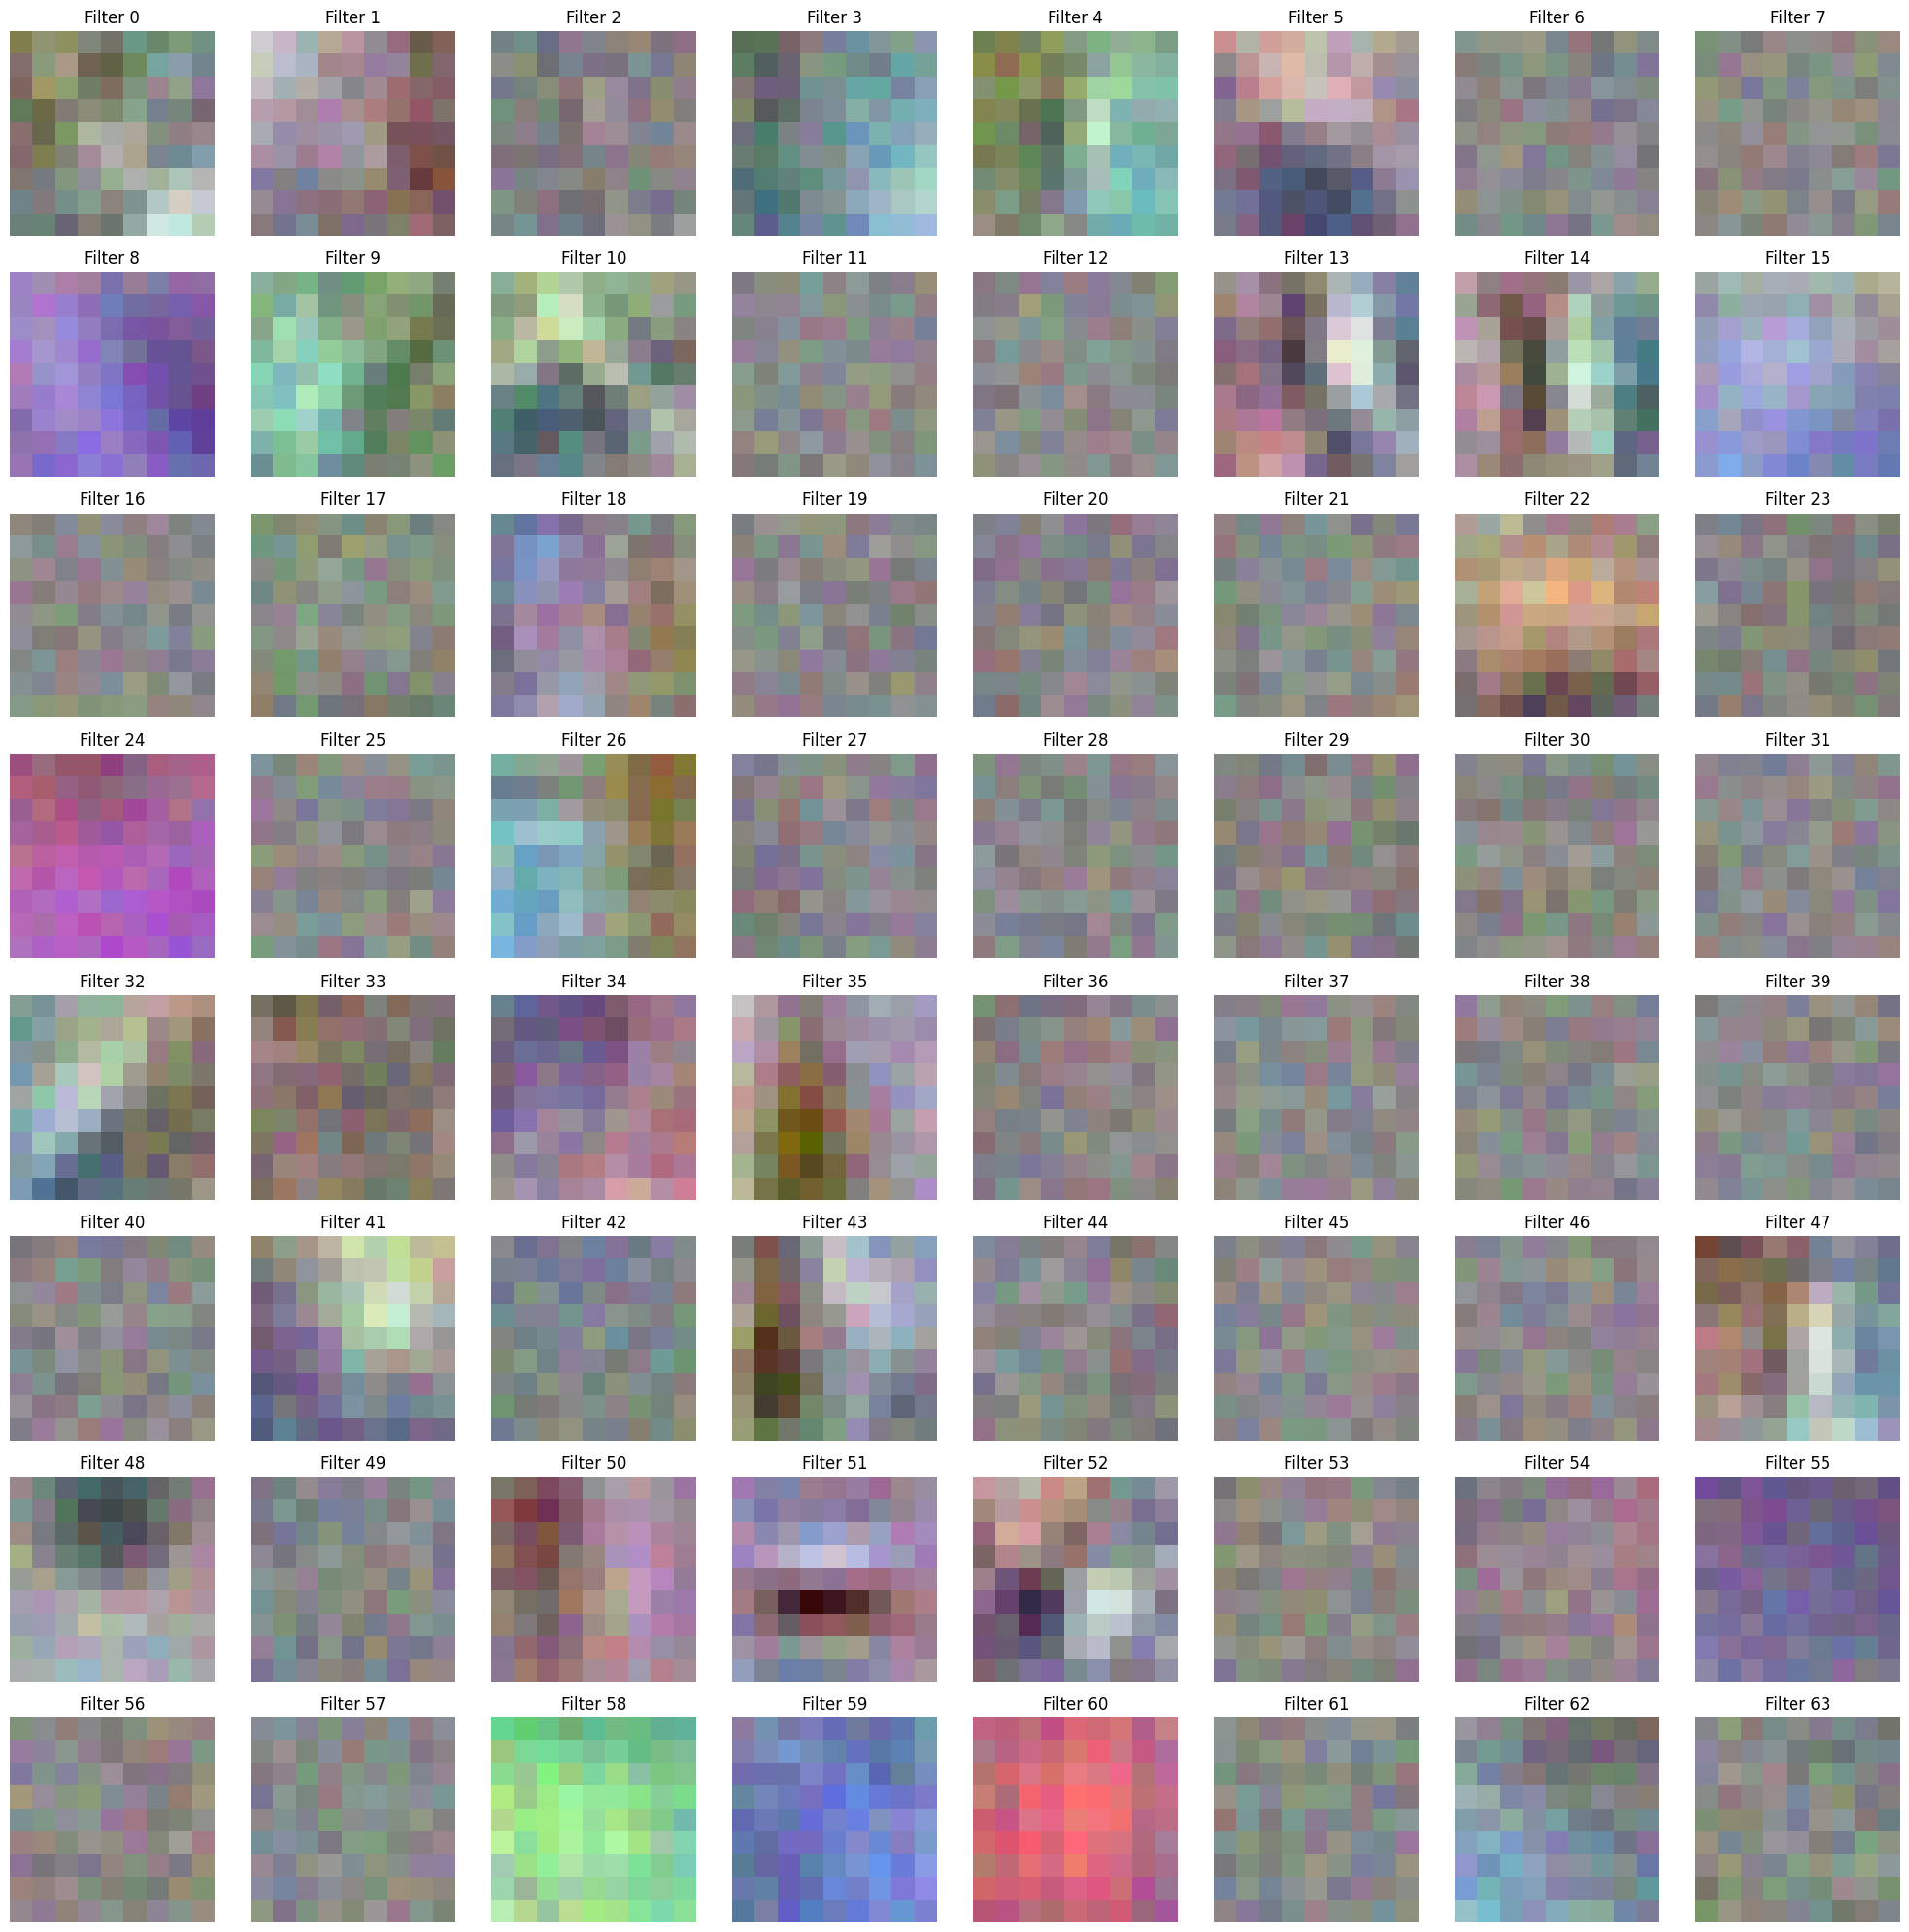

In [79]:
fig, axs = plt.subplots(
    8,
    8,
    figsize=(20, 20)
)

axs = axs.ravel()

for i in range(
    min(64, scaled_weights.shape[-1])
):

    filter_img = scaled_weights[:, :, :, i]

    axs[i].imshow(filter_img)
    axs[i].set_title(
        "Filter " + str(i)
    )
    axs[i].axis("off")

plt.tight_layout()
plt.show()